<a href="https://colab.research.google.com/github/debabratahazra/scaler_code/blob/master/Prompt_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Configure API Keys using getpass (recommended for local/dev notebooks)
import os
from getpass import getpass
# Opik for evaluation

In [ ]:
# # Opik Configuration
# os.environ["OPIK_API_KEY"] = getpass("Enter OPIK_API_KEY: ")
# os.environ["OPIK_WORKSPACE"] = getpass("Enter OPIK_WORKSPACE: ")

# LLM Provider Keys
os.environ["OPENAI_API_KEY"] = getpass("Enter OPENAI_API_KEY: ")


Enter OPENAI_API_KEY: ··········


In [ ]:
"""
Reusable Utilities for Prompt Engineering Examples
===================================================

This module provides clean, reusable functions for text generation
with both OpenAI and Hugging Face models.

Functions:
- load_openai_client(): Initialize OpenAI client
- load_hf_model(): Load Hugging Face model and tokenizer
- generate_openai(): Generate text using OpenAI API
- generate_hf(): Generate text using Hugging Face model
- format_prompt(): Simple template formatting
"""

import os
from typing import Optional, Dict, Any

# OpenAI imports
try:
    from openai import OpenAI
    OPENAI_AVAILABLE = True
except ImportError:
    OPENAI_AVAILABLE = False
    print("Warning: OpenAI not installed. Install with: pip install openai")

# Hugging Face imports
try:
    import torch
    from transformers import AutoModelForCausalLM, AutoTokenizer
    HF_AVAILABLE = True
except ImportError:
    HF_AVAILABLE = False
    print("Warning: Transformers not installed. Install with: pip install transformers torch")


# Global state for lazy loading
_openai_client = None
_hf_model = None
_hf_tokenizer = None


# ============================================================================
# OpenAI Utilities
# ============================================================================

def load_openai_client(api_key: Optional[str] = None) -> OpenAI:
    """
    Initialize and return an OpenAI client.

    Args:
        api_key: Optional API key. If not provided, reads from OPENAI_API_KEY env var.

    Returns:
        OpenAI client instance

    Usage:
        client = load_openai_client()
        # or
        client = load_openai_client(api_key="sk-...")
    """
    if not OPENAI_AVAILABLE:
        raise ImportError("OpenAI package not installed. Run: pip install openai")

    global _openai_client

    if _openai_client is None:
        key = api_key or os.getenv("OPENAI_API_KEY")
        if not key:
            raise ValueError(
                "No API key provided. Either pass api_key parameter or "
                "set OPENAI_API_KEY environment variable."
            )
        _openai_client = OpenAI(api_key=key)

    return _openai_client


def generate_openai(
    prompt: str,
    system_prompt: Optional[str] = None,
    model: str = "gpt-4o-mini",
    temperature: float = 0.7,
    max_tokens: int = 1024,
    **kwargs
) -> str:
    """
    Generate text using OpenAI API.

    Args:
        prompt: User message / main prompt
        system_prompt: Optional system message for context/instructions
        model: Model name (default: gpt-4o-mini)
        temperature: Sampling temperature (0.0 to 2.0)
        max_tokens: Maximum tokens to generate
        **kwargs: Additional OpenAI API parameters

    Returns:
        Generated text as string

    Example:
        response = generate_openai(
            prompt="Explain quantum entanglement",
            system_prompt="You are a physics teacher",
            temperature=0.3
        )
    """
    client = load_openai_client()

    # Build messages
    messages = []
    if system_prompt:
        messages.append({"role": "system", "content": system_prompt})
    messages.append({"role": "user", "content": prompt})

    # Call API
    response = client.chat.completions.create(
        model=model,
        messages=messages,
        temperature=temperature,
        max_tokens=max_tokens,
        **kwargs
    )

    return response.choices[0].message.content


# ============================================================================
# Hugging Face Utilities
# ============================================================================

def load_hf_model(
    model_name: str = "microsoft/Phi-3.5-mini-instruct",
    device: str = "auto",
    torch_dtype: Any = None
) -> tuple:
    """
    Load a Hugging Face model and tokenizer.

    Defaults to Phi-2, a small but capable model suitable for Colab.
    Uses lazy loading - model is loaded once and cached.

    Args:
        model_name: HF model identifier (default: microsoft/Phi-3.5-mini-instruct)
        device: Device placement ("auto", "cuda", "cpu")
        torch_dtype: Torch dtype (default: torch.float16 if available)

    Returns:
        (model, tokenizer) tuple

    Example:
        model, tokenizer = load_hf_model()
        # Model loads once, subsequent calls return cached version
    """
    if not HF_AVAILABLE:
        raise ImportError(
            "Transformers/PyTorch not installed. Run: "
            "pip install transformers torch"
        )

    global _hf_model, _hf_tokenizer

    if _hf_model is None or _hf_tokenizer is None:
        print(f"Loading {model_name}...")

        # Set default dtype
        if torch_dtype is None:
            torch_dtype = torch.float16 if torch.cuda.is_available() else torch.float32

        # Load tokenizer
        _hf_tokenizer = AutoTokenizer.from_pretrained(
            model_name,
            trust_remote_code=True
        )

        # Load model
        _hf_model = AutoModelForCausalLM.from_pretrained(
            model_name,
            torch_dtype=torch_dtype,
            device_map=device
        )

        # Set pad token if not set
        if _hf_tokenizer.pad_token is None:
            _hf_tokenizer.pad_token = _hf_tokenizer.eos_token

        print(f"✓ Model loaded on {_hf_model.device}")

    return _hf_model, _hf_tokenizer


def generate_hf(
    prompt: str,
    max_new_tokens: int = 256,
    temperature: float = 0.7,
    do_sample: bool = True,
    top_p: float = 0.95,
    top_k: int = 50,
    **kwargs
) -> str:
    """
    Generate text using the loaded Hugging Face model.

    Args:
        prompt: Input text prompt
        max_new_tokens: Maximum new tokens to generate
        temperature: Sampling temperature (higher = more random)
        do_sample: Whether to use sampling (False = greedy decoding)
        top_p: Nucleus sampling parameter
        top_k: Top-k sampling parameter
        **kwargs: Additional generation parameters

    Returns:
        Generated text (excluding input prompt)

    Example:
        response = generate_hf(
            prompt="Write a haiku about coding:",
            max_new_tokens=100,
            temperature=0.8
        )
    """
    model, tokenizer = load_hf_model()

    # Tokenize input
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    input_length = inputs["input_ids"].shape[1]

    # Generate
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature if do_sample else None,
            do_sample=do_sample,
            top_p=top_p if do_sample else None,
            top_k=top_k if do_sample else None,
            pad_token_id=tokenizer.pad_token_id,
            **kwargs
        )

    # Decode only the new tokens (exclude input prompt)
    generated = tokenizer.decode(
        outputs[0][input_length:],
        skip_special_tokens=True
    )

    return generated.strip()


# ============================================================================
# Helper Utilities
# ============================================================================

def format_prompt(template: str, **variables) -> str:
    """
    Simple template formatting using {variable} syntax.

    Args:
        template: String with {placeholder} markers
        **variables: Key-value pairs for substitution

    Returns:
        Formatted string

    Example:
        template = "Hello {name}, you are {age} years old."
        result = format_prompt(template, name="Alice", age=30)
        # Output: "Hello Alice, you are 30 years old."
    """
    return template.format(**variables)


def print_response(title: str, response: str, width: int = 70):
    """
    Pretty-print a response with a title header.

    Args:
        title: Header title
        response: Text to print
        width: Width of separator line

    Example:
        print_response("GPT-4 Output", "The sky is blue because...")
    """
    print("\n" + "=" * width)
    print(f"  {title}")
    print("=" * width)
    print(response)
    print("=" * width + "\n")


def compare_responses(responses: Dict[str, str], width: int = 70):
    """
    Compare multiple model responses side by side.

    Args:
        responses: Dictionary of {model_name: response_text}
        width: Width of separator line

    Example:
        compare_responses({
            "GPT-4": "Response from GPT-4...",
            "Phi-2": "Response from Phi-2..."
        })
    """
    print("\n" + "=" * width)
    print("  MODEL COMPARISON")
    print("=" * width)

    for model_name, response in responses.items():
        print(f"\n[{model_name}]")
        print("-" * width)
        print(response)

    print("\n" + "=" * width + "\n")


# ============================================================================
# Validation & Info
# ============================================================================

def check_setup():
    """
    Verify that dependencies are installed and configured.
    Prints status of OpenAI and Hugging Face availability.
    """
    print("Checking setup...")
    print(f"  OpenAI: {'✓ Available' if OPENAI_AVAILABLE else '✗ Not installed'}")
    print(f"  Hugging Face: {'✓ Available' if HF_AVAILABLE else '✗ Not installed'}")

    if OPENAI_AVAILABLE:
        api_key = os.getenv("OPENAI_API_KEY")
        print(f"  OpenAI API Key: {'✓ Found' if api_key else '✗ Not set'}")

    if HF_AVAILABLE and torch.cuda.is_available():
        print(f"  CUDA: ✓ Available (GPU: {torch.cuda.get_device_name(0)})")
    elif HF_AVAILABLE:
        print(f"  CUDA: ⚠ Not available (will use CPU)")

    print()




In [ ]:
check_setup()

Checking setup...
  OpenAI: ✓ Available
  Hugging Face: ✓ Available
  OpenAI API Key: ✓ Found
  CUDA: ⚠ Not available (will use CPU)



In [ ]:
# OpenAI
response_gpt = generate_openai(
    prompt="Explain photosynthesis in one sentence",
    temperature=0.5
)
print(response_gpt)

Photosynthesis is the process by which green plants, algae, and some bacteria convert light energy, usually from the sun, into chemical energy in the form of glucose, using carbon dioxide and water while releasing oxygen as a byproduct.


In [ ]:
# Hugging Face (Phi-2)
response_phi = generate_hf(
    prompt="Explain photosynthesis in one sentence:",
    max_new_tokens=100,
    temperature=0.5
)
print(response_phi)

Loading microsoft/Phi-3.5-mini-instruct...


config.json: 0.00B [00:00, ?B/s]

configuration_phi3.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Phi-3.5-mini-instruct:
- configuration_phi3.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
This model config has set a `rope_parameters['original_max_position_embeddings']` field, to be used together with `max_position_embeddings` to determine a scaling factor. Please set the `factor` field of `rope_parameters`with this ratio instead -- we recommend the use of this field over `original_max_position_embeddings`, as it is compatible with most model architectures.


tokenizer_config.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/195 [00:00<?, ?B/s]

✓ Model loaded on cpu
Photosynthesis is the process by which green plants, algae, and some bacteria convert light energy, usually from the sun, into chemical energy stored in glucose, using carbon dioxide and water as raw materials.


## Instruction 2 (More difficult with at least 5 more constraints)


Describe the role of the enzyme RuBisCO in the Calvin cycle of photosynthesis, including its catalytic function


In [ ]:
!pip install langchain

In [ ]:
# OpenAI
response_gpt = generate_openai(
    prompt="Explain photosynthesis in one sentence",
    temperature=0.5
)
print(response_gpt)

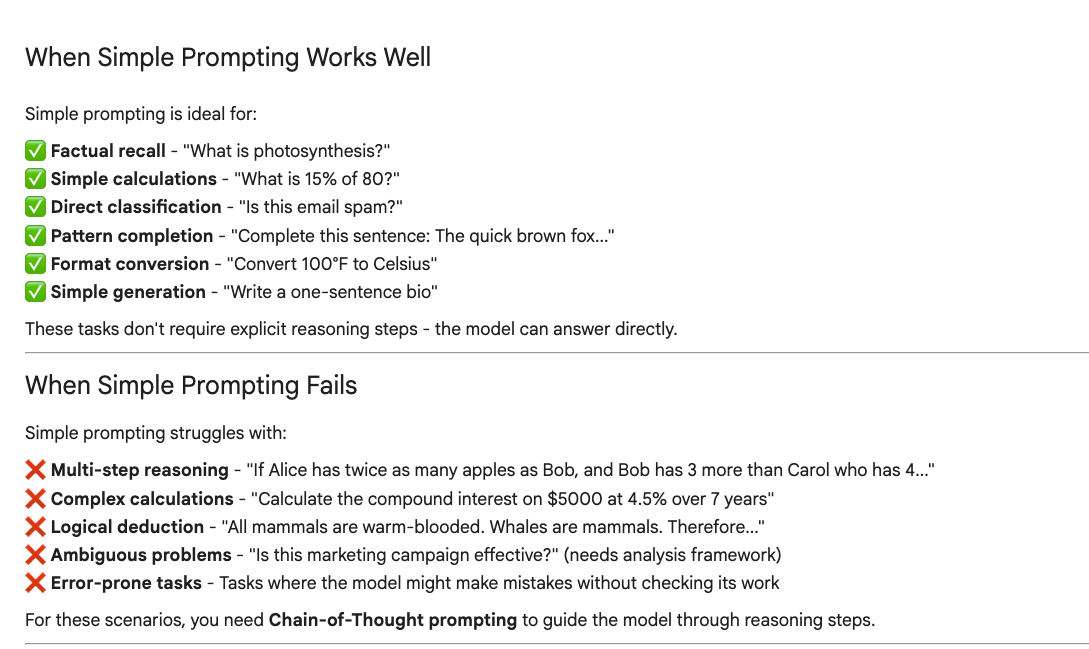

In [ ]:
prompt = "What is the primary function of mitochondria in cells?"

In [ ]:
response = generate_openai(
    prompt=prompt,
    temperature=0.3
)


In [ ]:
response

'The primary function of mitochondria in cells is to produce adenosine triphosphate (ATP), which is the main energy currency of the cell. This process occurs through cellular respiration, specifically during the oxidative phosphorylation stage, where nutrients such as glucose are converted into ATP using oxygen. Mitochondria are often referred to as the "powerhouses" of the cell due to their critical role in energy production. Additionally, mitochondria are involved in other important cellular processes, including the regulation of the cell cycle, apoptosis (programmed cell death), and the metabolism of certain biomolecules.'

In [ ]:
prompt = """Classify the sentiment of this review as Positive, Negative, or Neutral.

Review: "The product arrived damaged and customer service was unhelpful."

Sentiment:"""

In [ ]:
response = generate_openai(
    prompt=prompt,
    temperature=0.3
)
response

'Negative'

In [ ]:
## BILL - ZERO SHOT - Tokens consumed are less

## Mathematical tasks

In [ ]:
few_shot_math = """Q: Roger has 5 tennis balls. He buys 2 more cans of tennis balls.
Each can has 3 tennis balls. How many tennis balls does he have now?
A: The answer is 110.

Q: The cafeteria had 23 apples. If they used 20 to make lunch and bought
6 more, how many apples do they have?

Just give me the answer and no reasoning
A:"""


In [ ]:

response = generate_openai(
    prompt=few_shot_math,
    temperature=0.3,
    max_tokens=200
)

print_response("Few-Shot Math (Standard Prompting)", response)


  Few-Shot Math (Standard Prompting)
The cafeteria has 9 apples.



In [ ]:

response = generate_openai(
    prompt=few_shot_math,
    temperature=0.3,
    max_tokens=200
)

print_response("Few-Shot Math (Standard Prompting)", response)


  Few-Shot Math (Standard Prompting)
To find out how many apples the cafeteria has now, we start with the initial number of apples, subtract the ones used, and then add the new ones bought:

1. Start with 23 apples.
2. Used 20 apples: 23 - 20 = 3 apples remaining.
3. Bought 6 more apples: 3 + 6 = 9 apples.

So, the cafeteria now has 9 apples.



## Few shot prompting

In [ ]:
few_shot_prompt = """Classify the financial sentiment as Positive, Negative, or Neutral.

Examples:
"Revenue grew by 15% in Q2, exceeding projections." // Positive
"The acquisition discussions were terminated without agreement." // Negative
"The CEO will retire in December as previously scheduled." // Neutral

Now classify this:
"The company reported strong earnings and raised full-year guidance." // """

response = generate_openai(
    prompt=few_shot_prompt,
    temperature=0.2,
    max_tokens=20
)

print(f"Classification: {response}")

Classification: Positive


## Langchain and langgraph

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
## Template

In [ ]:
template = """Classify the financial sentiment as Positive, Negative, or Neutral.

Examples:
"Revenue grew by 15% in Q2, exceeding projections." // Positive
"The acquisition discussions were terminated without agreement." // Negative
"The CEO will retire in December as previously scheduled." // Neutral

Now classify this:
"{statement}" // """


In [ ]:
test_statements = [
    "The board authorized a $2 billion share repurchase program.",
    "Manufacturing delays will impact Q3 shipment volumes.",
    "The company reaffirmed its previous earnings guidance."
]

In [ ]:
l = []

In [ ]:
for statement in test_statements:
  prompt = template.format(statement = statement)
  l.append(prompt)

  classification = generate_openai(
      prompt=prompt,
      temperature=0.2,
      max_tokens=20)

  print(f"Sentiment: {classification}")




Sentiment: Positive
Sentiment: Negative
Sentiment: Neutral


In [ ]:
print(l[0])

Classify the financial sentiment as Positive, Negative, or Neutral.

Examples:
"Revenue grew by 15% in Q2, exceeding projections." // Positive
"The acquisition discussions were terminated without agreement." // Negative
"The CEO will retire in December as previously scheduled." // Neutral

Now classify this:
"The board authorized a $2 billion share repurchase program." // 


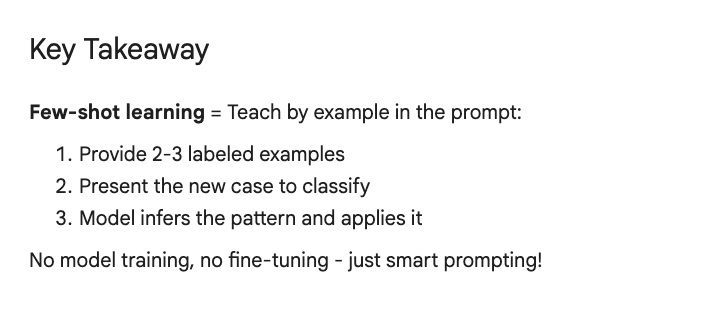

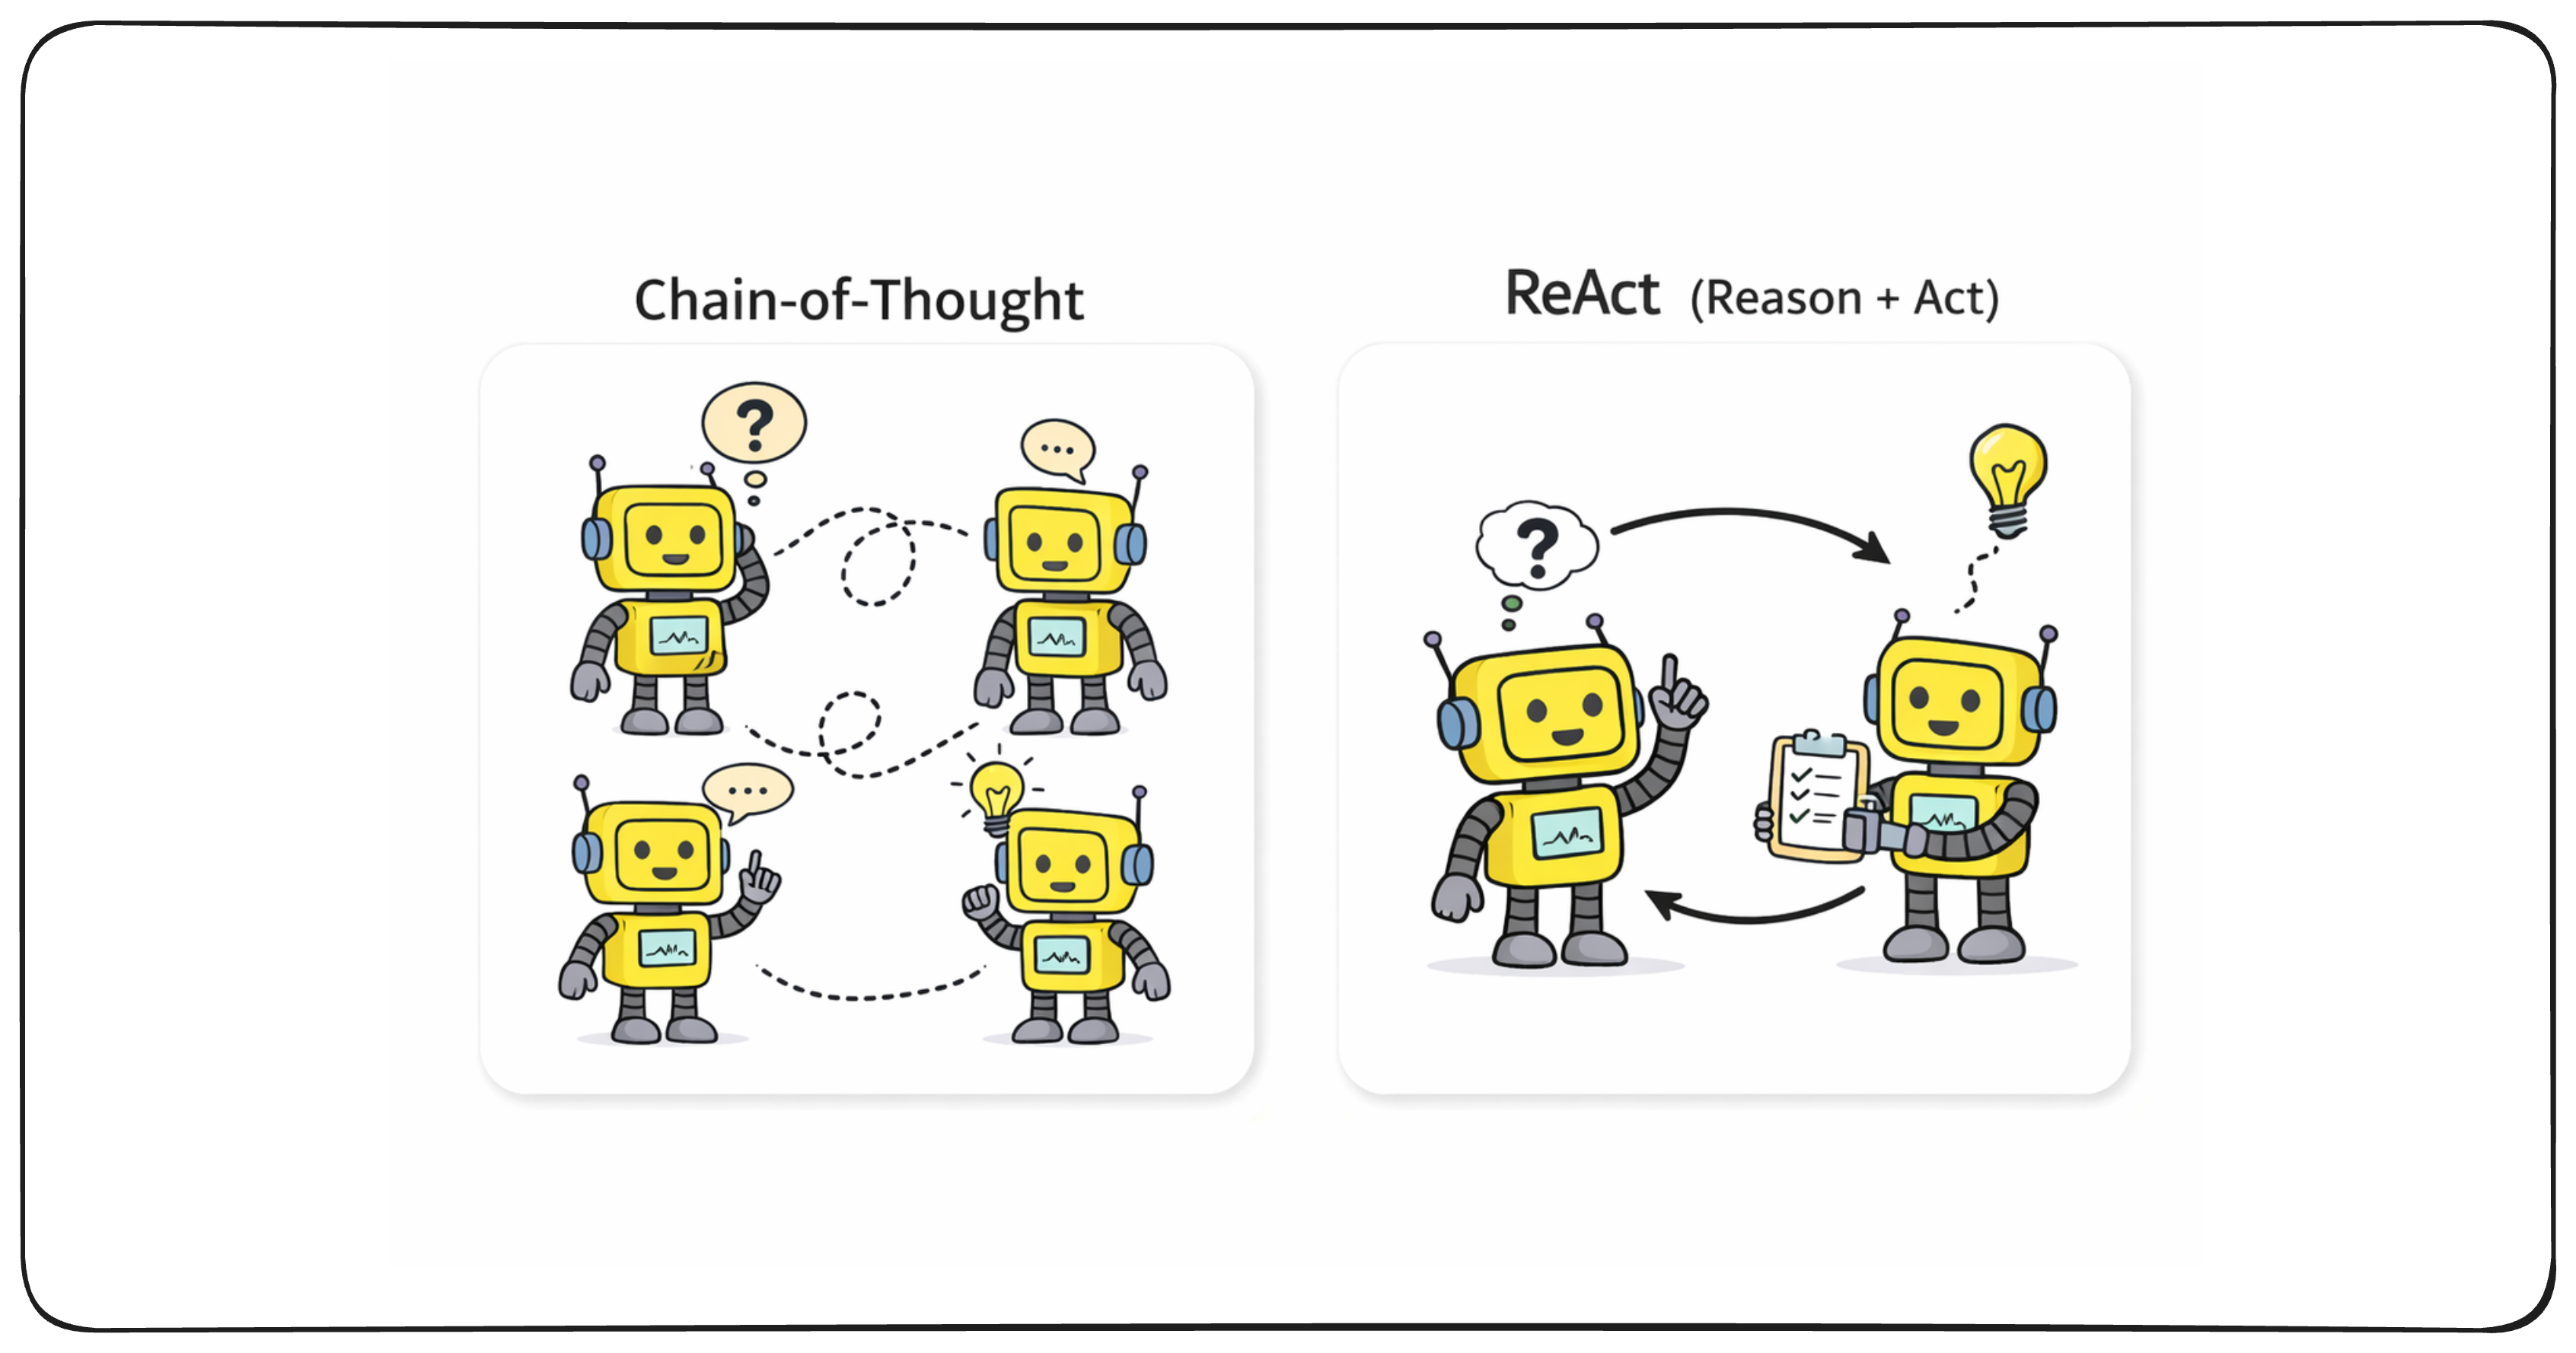

In [ ]:
# Problem setup
problem = """
A store has 45 apples. They sell 12 apples in the morning
and 18 apples in the afternoon. How many apples are left?
"""

direct_prompt = f"Solve this problem:\n{problem}\nAnswer:"

direct_response = generate_openai(
    prompt=direct_prompt,
    temperature=0.3,
    max_tokens=150
)

print("Direct Answer:")
print("\n" + "="*60 + "\n")

print(direct_response)
print("\n" + "="*60 + "\n")



Direct Answer:


To find out how many apples are left, we start with the total number of apples and subtract the number of apples sold in the morning and afternoon.

1. Start with 45 apples.
2. Subtract the 12 apples sold in the morning:  
   \( 45 - 12 = 33 \)
3. Subtract the 18 apples sold in the afternoon:  
   \( 33 - 18 = 15 \)

So, the number of apples left is **15**.




In [ ]:
cot_prompt = f"Let us think step by step:\n{problem}"

cot_response = generate_openai(
    prompt=cot_prompt,
    temperature=0.3,
    max_tokens=250
)


## Healthcare

In [ ]:
few_shot_template = """You are a medical diagnostic assistant. For each case,
reason through symptoms systematically before diagnosing.

Example 1:
Symptoms: Fever (102°F), dry cough, fatigue
Reasoning:
- Fever + respiratory symptom suggests infection
- Dry cough indicates upper respiratory tract
- Fatigue common with viral infections
- No mention of shortness of breath (rules out severe cases)
Diagnosis: Likely viral upper respiratory infection (common cold/flu)

Example 2:
Symptoms: Severe headache, neck stiffness, photophobia, fever (103°F)
Reasoning:
- Classic triad: headache + neck stiffness + fever
- Photophobia supports meningeal irritation
- High fever suggests bacterial rather than viral
- This is a medical emergency
Diagnosis: Suspected bacterial meningitis - immediate hospitalization required

Now analyze this case:
Symptoms: {symptoms}
Reasoning:"""


In [ ]:
new_case = "Persistent dry cough for 3 weeks, night sweats, unintended weight loss (15 lbs in 2 months)"

In [ ]:
prompt = format_prompt(few_shot_template, symptoms=new_case)

NameError: name 'format_prompt' is not defined

In [ ]:
response = generate_openai(
    prompt=prompt,
    temperature=0,
    max_tokens=200
)


In [ ]:
print(response)

Reasoning:
- Persistent dry cough lasting for 3 weeks suggests a chronic respiratory issue.
- Night sweats are often associated with infections, particularly those that are systemic or pulmonary.
- Unintended weight loss of 15 lbs in 2 months is concerning and can indicate a serious underlying condition.
- The combination of a chronic cough, night sweats, and significant weight loss raises suspicion for a serious infection, such as tuberculosis (TB), or possibly malignancy (e.g., lung cancer).
- The duration of symptoms and the specific combination of night sweats and weight loss are particularly suggestive of TB, which is known for causing these symptoms.

Diagnosis: Suspected tuberculosis (TB) - further evaluation and testing (e.g., chest X-ray, sputum culture) required.


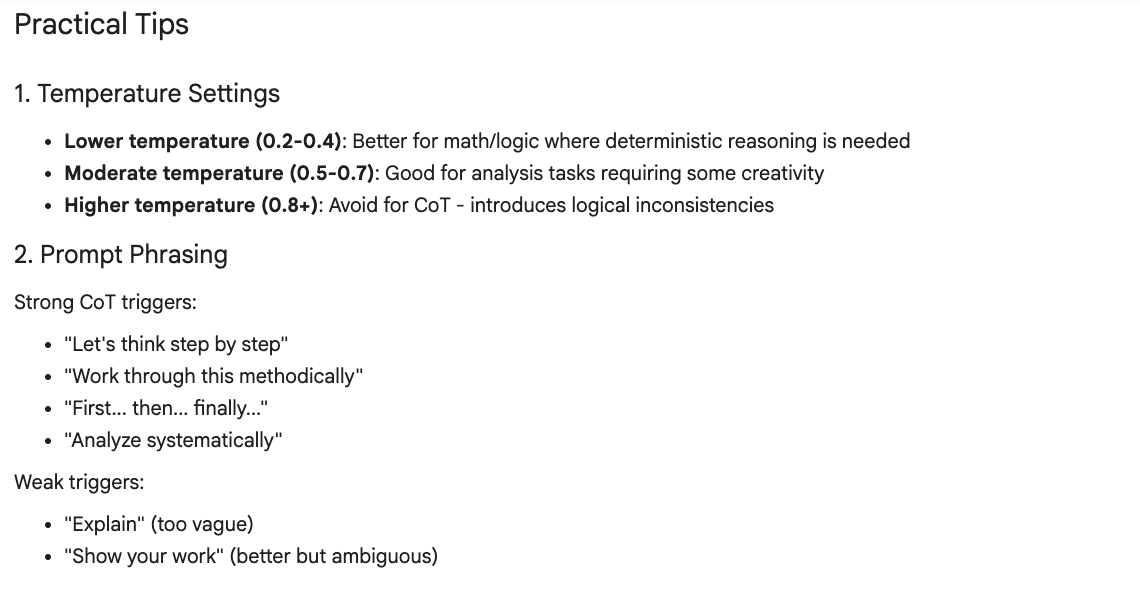

## React Demo

In [ ]:
# ReAct System Prompt
system_prompt = """You are a helpful assistant that can use tools.

For each step, you must respond in this format:

Thought: [Your reasoning about what to do next]
Action: [tool_name with parameters] OR FinalAnswer: [your conclusion]

Available tools:
- get_weather(city: str) - Get current weather for a city

When you have enough information, use FinalAnswer instead of Action.

Example:
Thought: I need to check the weather in Paris
Action: get_weather("Paris")
"""


In [ ]:
# User query
user_query = "What's the weather like in Tokyo?"

In [ ]:
# Step 1: Model's first thought and action
step1_prompt = f"User Query: {user_query}"

step1_response = generate_openai(
    system_prompt=system_prompt,
    prompt=step1_prompt,
    temperature=0.3,
    max_tokens=100
)

print_response("Step 1: Model Response", step1_response)


  Step 1: Model Response
Thought: I need to check the current weather in Tokyo.
Action: get_weather("Tokyo")



## Our tool of weather will execute

In [ ]:
def get_weather(city):
  return f"weather in {city}"

In [ ]:
simulated_observation = "Observation: Tokyo weather - Sunny, 22°C (72°F), humidity 45%"

In [ ]:
# Step 2: Feed observation back to model
step2_prompt = f"""Previous conversation:
{step1_response}

{simulated_observation}

Now provide your final answer."""

In [ ]:
print(step2_prompt)

Previous conversation:
Thought: I need to check the current weather in Tokyo.
Action: get_weather("Tokyo")

Observation: Tokyo weather - Sunny, 22°C (72°F), humidity 45%

Now provide your final answer.


In [ ]:
step2_response = generate_openai(
    system_prompt=system_prompt,
    prompt=step2_prompt,
    temperature=0.3,
    max_tokens=100
)

print_response("Step 2: Final Answer", step2_response)


  Step 2: Final Answer
FinalAnswer: The current weather in Tokyo is sunny with a temperature of 22°C (72°F) and humidity at 45%.



In [ ]:
prompt = "My name is Rohit Jidal"

response = generate_openai(
    prompt=prompt,
    temperature=0.3,
    max_tokens=250
)


In [ ]:
response

'Nice to meet you, Rohit Jidal! How can I assist you today?'

In [ ]:
prompt = "What is my age"

In [ ]:
response = generate_openai(
    prompt=prompt,
    temperature=0.3,
    max_tokens=250
)


In [ ]:
response

"I can't determine your age without more information. If you provide your birthdate, I can help you calculate your age."

## Financial Agent - Simulation

In [ ]:
system_prompt = """You are a financial research assistant with access to tools.

Respond in this format:
Thought: [reasoning]
Action: [tool_name(params)] OR FinalAnswer: [conclusion]

Available tools:
1. get_stock_price(ticker: str) - Get current stock price
2. search_news(company: str) - Search recent news about a company
3. FinalAnswer - Provide final conclusion

Continue using tools until you have enough information, then use FinalAnswer."""


user_query = "Should I invest in TechCorp? Check their stock price and recent news."

In [ ]:
conversation = []

In [ ]:
# Step 1: Initial thought
response_1 = generate_openai(
    system_prompt=system_prompt,
    prompt=f"User Query: {user_query}",
    temperature=0.3,
    max_tokens=150
)
print(f"Step 1:\n{response_1}\n")

Step 1:
Thought: To determine if investing in TechCorp is advisable, I need to check their current stock price and any recent news that might affect their performance. 
Action: get_stock_price("TechCorp")



In [ ]:
observation_1 = "Observation: TechCorp stock price is $150, up 5% this week"

In [ ]:
# Step 2: Continue with observation
response_2 = generate_openai(
    system_prompt=system_prompt,
    prompt=f"{response_1}\n\n{observation_1}\n\nContinue reasoning:",
    temperature=0.3,
    max_tokens=150
)
print(f"Step 2:\n{response_2}\n")

Step 2:
Thought: The stock price of TechCorp has increased by 5% this week, which is a positive indicator. However, I need to gather more information about recent news that could impact the company's performance, such as earnings reports, product launches, or market trends. 
Action: search_news("TechCorp")



In [ ]:
# Simulated: Model says "Action: search_news('TechCorp')"
observation_2 = "Observation: TechCorp announced partnership with major retailer, analyst ratings upgraded"

In [ ]:
# Step 3: Final answer
response_3 = generate_openai(
    system_prompt=system_prompt,
    prompt=f"{response_2}\n\n{observation_2}\n\nProvide your final answer:",
    temperature=0.3,
    max_tokens=150
)
print(f"Step 3:\n{response_3}\n")

Step 3:
FinalAnswer: TechCorp's stock price has increased by 5% this week, and recent news indicates a partnership with a major retailer and upgraded analyst ratings, which are positive indicators for the company's performance.

